# **Colabユーザーへの注意**

# **このファイルに直接書き込まないでください—作業が消えることがあります！**

# **必ず作業前にコピーを作成してください。**

コピーの作り方

1. 左上の「File」をクリック  
> *「File」や「Runtime」などのメニューが見えないときは、右上の“v”マークを押して表示してください。*

2. 「Save a copy in Drive」を選ぶ  

3. コピーしたファイル名を「YOURNAMEs_FileName.ipynb」に変更する  
> 例：名前がOliviaなら → Olivias_FileName.ipynb  


---

* チェックマーク（✅）は保存されません。Chromeのリロードボタンでページを更新すると消えます。<br>  
途中で止めるときは、テキストセルを追加して「SO FAR DONE」など書いておいてください。

---

* Colabでは**30分〜90分ごとに以前の出力結果がリセットされます**。<br>  
そのため、`~~ is not defined`のようなエラーが**すごくよく起こります**。

🔁 `~~ is not defined`エラーが出たらどうする？

1. まず変数名のスペルを確認してください。<br>  
2. スペルが正しいのにまだエラーが出るなら、**そのセルをクリックして選択**してください。<br>  
3. 左上の「Runtime」→「Run before」をクリック。<br>  
→ これで**それまでのすべてのセルが再実行されます**。  
4. 再度、そのセルを実行してください。

もしこれでもエラーが直らなければ、<br>  
前のセルのTODOの答えに基本的なミスがあるかもしれません。<br>  
正しいかどうか確認してください。<br>  
またはChatGPTや他のコーディングアシスタントに助けを求めましょう。

**参考文献**

Sebastian Raschka 著『Build a Large Language Model From Scratch』で参照されているコードです。

コードリポジトリ: https://github.com/rasbt/LLMs-from-scratch

名著へのリンク:
[Build a Large Language Model (From Scratch)](https://www.manning.com/books/build-a-large-language-model-from-scratch)

# **Chapter 29: Magpie**

このChapterでは、`Magpie`という少し不思議な現象を、自分で小さく再現してみます。

これまでのInstruction Tuningでは、たとえば `<USER>質問文<AI>回答文` という文章をそのまま学習していました。つまり、モデルは「質問文も回答文も、次の文字として当てる」練習をしていました。

今回は少しやり方を変えて、プロンプトをマスクします。すなわち、`<USER>質問文<AI>` の部分は入力としてモデルに見せますが、そこには損失を計算しません。損失を計算するのは、`回答文` の部分だけです。

言い換えると、モデルは質問文を読んで回答する練習はしますが、「質問文そのものを作る練習」は明示的には全くしていないことになります。

それなのに、学習後のモデルに `<USER>` だけを渡して続きを生成させると、まれに質問文のようなテキストが出てくることがあります。この現象は、[Magpie](https://arxiv.org/abs/2406.08464)という研究でも注目されています。

このChapterでは、プロンプトをマスクしたInstruction Tuningを実際に行い、「質問文を直接練習していないはずなのに、質問文らしいものが出てくる」様子を確かめていきます。

**出典**

Xu, Z., Jiang, F., Niu, L., Deng, Y., Poovendran, R., Choi, Y., & Lin, B. Y. (2024). *Magpie: Alignment data synthesis from scratch by prompting aligned LLMs with nothing*. arXiv. https://doi.org/10.48550/arXiv.2406.08464


**参考文献**

Sebastian Raschka 著『Build a Large Language Model From Scratch』で参照されているコードです。

コードリポジトリ: https://github.com/rasbt/LLMs-from-scratch

名著へのリンク:
[Build a Large Language Model (From Scratch)](https://www.manning.com/books/build-a-large-language-model-from-scratch)

## **Section 1: 事前学習モデルの読み込み**

今回もG4 GPUを使います。前回の事前学習で購入したクレジットの残りを使います。<br>
全くクレジットがない、、、！という方は、追加で100クレジットを購入してください、、、😭

**`Check Point`** <label><input type="checkbox">G4 GPUに接続したことを確認した<label>

まずは、前回訓練した事前学習モデルの重みを読み込みます。

前回と同じモデルクラスを定義し、同じconfigインスタンスを設定して、同じモデルインスタンスを作成します。

この時のモデルインスタンスのパラメータの値はランダムに初期化されています。

そして、huggingfaceのリポジトリから、チェックポイントをダウンロードします。

チェックポイントに保存されたパラメータの値を、モデルインスタンスに読み込みます。

モデルクラスは前回と同じです。

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class TokenEmbedding(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super().__init__()
        # 語彙数x埋め込み次元の埋め込みテーブルを定義する
        self.token_embedding_table = nn.Embedding(vocab_size, embedding_dim)

    def embed(self, input_indices):
        # 入力インデックスに対応する埋め込みベクトルを取得する
        return self.token_embedding_table.forward(input_indices)


class RelativePositionEmbedding(nn.Module):
    def __init__(self, config):
        super().__init__()
        # 相対位置バイアスの辞書の要素数を計算する
        # 相対位置は -(T-1) から +(T-1) までとりうるので、要素数は 2*T-1
        self.relative_position_count = 2 * config.input_sequence_length - 1
        self.bias_embedding_table = nn.Embedding(self.relative_position_count, 1)

    def forward(self, query_len, key_len, device_type=None):
        query_positions = torch.arange(query_len, device=device_type)[:, None]  # (query_len, 1)
        key_positions = torch.arange(key_len, device=device_type)[None, :]      # (1, key_len)
        relative_position_matrix = query_positions - key_positions

        # 相対位置indexを非負の値にシフトする(埋め込みテーブル参照用)
        relative_position_indices = relative_position_matrix + key_len - 1

        # 相対位置indexに対応するbias embeddingを取得する
        # (query_len, key_len, 1)
        relative_position_bias_embeddings = self.bias_embedding_table(relative_position_indices)

        # 不要な次元を削除する
        # (query_len, key_len)
        relative_position_bias_matrix = relative_position_bias_embeddings.squeeze(-1)

        return relative_position_bias_matrix

class AttentionHead(nn.Module):
    def __init__(self, head_size, config):
        super().__init__()
        self.key_fc= nn.Linear(config.embedding_dim, head_size, bias=False)
        self.query_fc = nn.Linear(config.embedding_dim, head_size, bias=False)
        self.value_fc = nn.Linear(config.embedding_dim, head_size, bias=False)

        self.head_size = head_size
        self.relative_position_embedding_layer = RelativePositionEmbedding(config=config)

    def forward(self, input_tensor):
        B, T, C = input_tensor.shape  # バッチ、トークン長、埋め込みチャネル

        Key = self.key_fc.forward(input_tensor)     # (B, T, head_size)
        Query = self.query_fc.forward(input_tensor)   # (B, T, head_size)
        Value = self.value_fc.forward(input_tensor)   # (B, T, head_size)

        # Attentionスコアを計算中 (QK^T) / sqrt(embedding_dim)
        attention_weights_before_mask = Query @ Key.transpose(-2, -1) * self.head_size**(-0.5)

        # 相対位置バイアスの補正項を計算する
        relative_position_bias_matrix = self.relative_position_embedding_layer(T, T, device_type=input_tensor.device)

        # 相対位置バイアスの補正項を加算する
        attention_weights_before_mask = attention_weights_before_mask + relative_position_bias_matrix

        # マスク適用済み
        mask = torch.triu(torch.ones(T, T), diagonal=1).to(input_tensor.device)
        masked_attention_weights = attention_weights_before_mask.masked_fill(mask == 1, float('-inf'))

        # ソフトマックス → ドロップアウト → 重み付き和
        attention_weights = F.softmax(masked_attention_weights, dim=-1)

        out = attention_weights @ Value  # (B, T, head_size)
        return out


class MultiHeadAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.num_attention_heads = config.num_attention_heads
        self.embedding_dim = config.embedding_dim
        self.head_size = int(self.embedding_dim / self.num_attention_heads)

        # ModuleListで複数のヘッドを管理する
        self.attention_heads = nn.ModuleList([
            AttentionHead(self.head_size, config)
            for _ in range(self.num_attention_heads)
        ])

        # 各ヘッドの出力を混合する線形層
        self.output_projection = nn.Linear(self.embedding_dim, self.embedding_dim)


    def forward(self, input_tensor):
        # 各ヘッドの出力を取得する
        # (B, T, head_size)のリスト
        head_outputs_list = [head.forward(input_tensor) for head in self.attention_heads]

        # 全てのヘッドの出力を連結 → (B, T, embedding_dim)
        concatenated = torch.cat(head_outputs_list, dim=-1)

        # 線形変換での出力混合
        projected = self.output_projection.forward(concatenated)

        return projected

class FeedForward(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(config.embedding_dim, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, config.embedding_dim),
        )

    def forward(self, input_tensor):
        return self.net(input_tensor)

class TransformerBlock(nn.Module):
    def __init__(self, config):
        super().__init__()

        # 各LayerNormは独自のbetaとgammaを保持します。
        self.layer_norm1 = nn.LayerNorm(config.embedding_dim)
        self.layer_norm2 = nn.LayerNorm(config.embedding_dim)

        self.multihead_attention = MultiHeadAttention(config=config)
        self.feed_forward = FeedForward(config=config)

    def forward(self, input_tensor):
        # forwardメソッドは省略されています。
        normed_input = self.layer_norm1(input_tensor) # 入力にレイヤーノルムを適用する
        attention_output = self.multihead_attention(normed_input) # マルチヘッドアテンションを適用する
        residual_attention = attention_output + input_tensor # "before! layernorm1"を追加
        normed_attention = self.layer_norm2(residual_attention) # 残差出力に再度LayerNormを適用する
        feedforward_output = self.feed_forward(normed_attention) # フィードフォワードネットワークを適用する
        final_output = feedforward_output + residual_attention # "before" layernorm2 を追加する！

        return final_output

class VocabularyLogits(nn.Module):
    def __init__(self, config):
        super().__init__()
        # レイヤー正規化
        self.output_norm = nn.LayerNorm(config.embedding_dim)
        # 語彙数の射影
        self.vocab_projection = nn.Linear(config.embedding_dim, config.vocab_size)

    def forward(self, transformer_block_output):
        # Transformerブロックの出力にLayer normalizationを適用する。
        normalized_output = self.output_norm.forward(transformer_block_output)  # (B, T, C)

        # 線形層でスコアを語彙数次元に変換する。
        vocab_logits = self.vocab_projection.forward(normalized_output)  # (B, T, V)

        return vocab_logits


In [ ]:
def generate_stream(model, input_indices, max_new_tokens, temperature=1.0, top_k=None, top_p=None):
    model.eval()
    with torch.no_grad():
        for _ in range(max_new_tokens):
            input_conditioned = input_indices[:, -model.config.input_sequence_length:]
            logits, _ = model(input_conditioned, target_indices=None)
            last_logits = logits[:, -1, :] / temperature

            if top_k is not None:
                values, _ = torch.topk(last_logits, min(top_k, last_logits.size(-1)))
                last_logits = last_logits.masked_fill(last_logits < values[:, [-1]], float('-inf'))

            if top_p is not None:
                sorted_logits, sorted_indices = torch.sort(last_logits, descending=True)
                cumulative_probs = torch.cumsum(F.softmax(sorted_logits, dim=-1), dim=-1)
                sorted_indices_to_remove = cumulative_probs > top_p
                sorted_indices_to_remove[:, 1:] = sorted_indices_to_remove[:, :-1].clone()
                sorted_indices_to_remove[:, 0] = False
                indices_to_remove = sorted_indices_to_remove.scatter(1, sorted_indices, sorted_indices_to_remove)
                last_logits = last_logits.masked_fill(indices_to_remove, float('-inf'))

            probs = F.softmax(last_logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)
            input_indices = torch.cat((input_indices, next_token), dim=1)
            yield input_indices


def generate(model, input_indices, max_new_tokens, temperature=1.0, top_k=None, top_p=None):
    generated_indices = input_indices
    for generated_indices in generate_stream(
        model,
        input_indices,
        max_new_tokens,
        temperature=temperature,
        top_k=top_k,
        top_p=top_p,
    ):
        pass
    return generated_indices

class EveryonesGPT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config  # 生成時にも使うので保持してください。
        self.token_embedding_layer = TokenEmbedding(vocab_size = config.vocab_size, embedding_dim = config.embedding_dim)
        self.blocks = nn.Sequential(*[TransformerBlock(config=config) for _ in range(config.layer_count)])
        self.vocab_projection = VocabularyLogits(config=config)
        # targetが-100の場所は、lossを計算しない
        self.criterion = nn.CrossEntropyLoss(ignore_index=-100)

    # 尤度と損失を計算する
    def forward(self, input_indices, target_indices):
        token_embeddings = self.token_embedding_layer.embed(input_indices)
        blocks_output = self.blocks(token_embeddings)
        logits = self.vocab_projection(blocks_output)

        # 推論時はターゲットがないため、lossはNoneです
        # —確率（ロジット）のみ返されます。
        if target_indices is None:
            return logits, None

        batch_size, token_len, vocab_size = logits.shape
        logits = logits.view(batch_size * token_len, vocab_size)
        targets = target_indices.view(batch_size * token_len)
        loss = self.criterion(logits, targets)

        return logits, loss

    # テキストを生成する


Configクラスについても、前回と同じです。

In [ ]:
class Config:
    vocab_size = 50257
    # === training ===
    batch_size: int = 32 # 85GB VRAM
    total_steps: int = 100_000
    checkpoint_save_frequency: int = 10_000
    input_sequence_length: int = 1024

    # === model ===
    embedding_dim: int = 1280
    hidden_dim: int = 5120
    num_attention_heads: int = 10
    layer_count: int = 20

    # === optimization ===
    max_learning_rate: float = 2e-4
    min_learning_rate: float = 2e-5
    warmup_steps: int = 1_000

    # === system ===
    device_type: str = "cuda"

In [ ]:
config = Config()

モデルのインスタンスを作成します。この時、モデルのパラメータ（重みやバイアス）は、ランダムに初期化されています。

そのため、まだGPUには転送しません。GPUに転送するのは、事前学習モデルのパラメータの値を読み込んだ後です。

⚠️ 穴埋め部分あり。モデルクラスを命名してください。

In [ ]:
vocab_size = 50257
# GPUにはまだ転送しない。
model = EveryonesGPT(config = config)

前回同様、高速化のために、モデルに対してコンパイルという処理をします。

In [ ]:
# ⚠️ Don't run this cell twice!
torch.backends.cuda.matmul.allow_tf32 = True
torch.set_float32_matmul_precision("high")
compiled_model = torch.compile(model)

現在は、モデルのパラメータ（重みやバイアス）はランダムに初期化されています。

いわば、骨組みはあるが、中身が未完な状態です。

前回の事前学習のチェックポイント`checkpoints/checkpoint_010000.pt`をダウンロードします。

次に、モデルの重みやバイアスの値`checkpoint_data["model_state_dict"]`を取得します。

そして、これを先ほどのモデルのインスタンスに読み込ませます。

HuggingFaceにログインします。

In [ ]:
from huggingface_hub import login
login()

前回の事前学習のチェックポイントをダウンロードします。

In [ ]:
from huggingface_hub import hf_hub_download
model_repo_id = # TODO: FILL 自分のレポジトリを使用する。 例: "aoUTlum/EveryonesGPT-checkpoints"
checkpoint_path = # TODO: FILL 自分の事前学習チェックポイントを使用する。例："checkpoints/checkpoint_010000.pt"
hf_hub_download(repo_id=model_repo_id, repo_type="model", filename=checkpoint_path, local_dir=".")

checkpoints/checkpoint_099000.pt:   0%|          | 0.00/6.27G [00:00<?, ?B/s]

'checkpoints/checkpoint_099000.pt'

```python
出力: checkpoint_data（チェックポイントファイルから読み込んだ辞書。例: "model_state_dict" などを含む）
関数: torch.load
引数: checkpoint_path（読み込む .pt のパス）, map_location="cpu"（CPU上に読み込む）
```
- `checkpoint_path`で指定したチェックポイント（`.pt`）を読み込み、Pythonの辞書として受け取る。
- `checkpoint_data`を丸ごとGPU上にロードする意味はありません。なぜなら、後で`checkpoint_data`に含まれる中身`model_state_dict`だけを使いたいからです。したがって、`cpu`上にロードします。

In [ ]:
checkpoint_data = torch.load(checkpoint_path, map_location="cpu")  # TODO: 出力 = 関数(引数)

```python
出力: なし
インスタンス: compiled_model（モデルのインスタンス。現在はパラメータの値はランダムに初期化されている。）
メソッド: load_state_dict
引数: THINK_BY_YOURSELF（保存済みのパラメータ辞書）
```
- チェックポイント内の `"model_state_dict"` をモデルに適用して、学習済みの重み/バイアスを復元する。

In [ ]:
compiled_model.load_state_dict(checkpoint_data["model_state_dict"])  # TODO: インスタンス.メソッド(引数)

<All keys matched successfully>

モデルのインスタンスに、事前学習モデルのパラメータの値を読み込むことができました。

これをGPU上に転送します。

In [ ]:
compiled_model.to("cuda")

OptimizedModule(
  (_orig_mod): EveryonesGPT(
    (token_embedding_layer): TokenEmbedding(
      (token_embedding_table): Embedding(50257, 1280)
    )
    (blocks): Sequential(
      (0): TransformerBlock(
        (layer_norm1): LayerNorm((1280,), eps=1e-05, elementwise_affine=True)
        (layer_norm2): LayerNorm((1280,), eps=1e-05, elementwise_affine=True)
        (multihead_attention): MultiHeadAttention(
          (attention_heads): ModuleList(
            (0-9): 10 x AttentionHead(
              (key_fc): Linear(in_features=1280, out_features=128, bias=False)
              (query_fc): Linear(in_features=1280, out_features=128, bias=False)
              (value_fc): Linear(in_features=1280, out_features=128, bias=False)
              (relative_position_embedding_layer): RelativePositionEmbedding(
                (bias_embedding_table): Embedding(1024, 1)
              )
            )
          )
          (output_projection): Linear(in_features=1280, out_features=1280, bias=True)
 

事前学習モデルの推論を確認してみましょう！

推論時のサンプリングパラメータ`temperature`を0.7に設定しています。

このため、LLMの出力は比較的高いランダム性があります。

5回、推論を行い、出力の傾向を確かめてください。

In [ ]:
import tiktoken
compiled_model.eval()
prompt = "What is the capital of Japan?"
tokenizer = tiktoken.get_encoding("gpt2")
encoded = tokenizer.encode(prompt, allowed_special="all") # テキストをIDにエンコード
encoded_tensor = torch.tensor(encoded, dtype=torch.long) # IDのリストをテンソルの形式に変換する
encoded_tensor = encoded_tensor.unsqueeze(0)  # バッチ次元追加
encoded_tensor = encoded_tensor.to(config.device_type) # cuda(GPU)にencoded_tensorを転送する
generated_tensor = generate(compiled_model, encoded_tensor, max_new_tokens=64, temperature=0.7)
generated_ids = generated_tensor.squeeze(0).tolist() # バッチ次元を削除してリストに変換する
generated_text = tokenizer.decode(generated_ids) # IDのリストをテキストにデコードする
print(generated_text)

What is the capital of Japan?
The capital of Japan is "the city of Japan."
Japan is the world’s largest economy with a population of 1.7 billion people and the GDP of Japan is estimated at US$7.8 billion. Japan is also the world’s fastest growing economy.
Japan’s population


**`Check Point`**
<label><input type="checkbox">↓以下と答えが一致したらチェックをつける</label>


```
What is the capital of Japan?
The capital of Japan is "the city of Japan."
Japan is the world’s largest economy with a population of 1.7 billion people and the GDP of Japan is estimated at US$7.8 billion. Japan is also the world’s fastest growing economy.
Japan’s population
```

**`Check Point`** <label><input type="checkbox">5回推論して、出力の傾向を確かめた。<label>

事前学習モデルは、ブログのような口調で永遠と解説したり、質問を繰り返したりします。

この事前学習モデルを、対話データで学習します。

これにより、質問に回答する便利なアシスタントへと微調整していきます。

|  | データ | モデル出力 |
|---|---|---|
| Pretraining | Webデータ | ブログ形式 |
| Instruction Tuning | 対話データ | 対話形式 |

なお、実は回答だけではなく、質問もモデルにより生成することができます。

これにより上記のような対話を、数十万サンプル、生成することができました。

このデータセットが[Magpie-Phi3-Pro-1M-v0.1](https://huggingface.co/datasets/Magpie-Align/Magpie-Phi3-Pro-1M-v0.1)です。

大規模かつMITライセンスという素晴らしいデータセットを、あなたの手元にダウンロードしましょう。

In [ ]:
from huggingface_hub import hf_hub_download

hf_hub_download(
    repo_id="HayatoHongo/Magpie-Phi3-Pro-1M-v0.1",
    repo_type="dataset",
    filename="sft_prompt_response_phi3.jsonl",
    local_dir=".",
)

sft_prompt_response_phi3.jsonl:   0%|          | 0.00/1.38G [00:00<?, ?B/s]

'sft_prompt_response_phi3.jsonl'

先頭のサンプルをいくつか確認してみましょう。

In [ ]:
!head "/content/sft_prompt_response_phi3.jsonl"

{"prompt": "What is the capital of Japan?", "response": "The capital of Japan is Tokyo."}
{"prompt": "Hello there!", "response": "Hello! How can I assist you today?"}
{"prompt": "What is the result of 2^3?", "response": "The result of 2^3 is 8."}
{"prompt": "Who _wrote_ \"Harry Potter\"?", "response": "J.K. Rowling wrote the \"Harry Potter\" series."}
{"prompt": "How many wheels does a tricycle have?", "response": "A tricycle has 3 wheels."}
{"prompt": "Who is the atomic number of Calcium? Call By Its Chemical Element Name?", "response": "The atomic number of Calcium is 20."}
{"prompt": "Mark was running faster than Sarah, yet Sarah still arrived earlier, because _ took a shortcut.", "response": "Sarah"}
{"prompt": "Can an external factor, like a cyberattack or power outage, cause the fatality tally in Ben in May to be higher than in June, assuming all figures from the Deaths Table are correct and consistent with public health records, and there are no unreported fatalities or natural 

## **Section 2: 擬似サンプル(通常版)**

ここでは、Instruction Tuningにprompt maskを入れると何が変わるのかを確認します。

prompt maskとは、prompt側の `target_ids` を `-100` にして、その部分のlossを計算しないようにすることです。

```text
<USER>Hello?<AI>Hi!<|endoftext|>
^^^^^^^^^^^^^^^  -------------------
target_id = -100  target_id = token id
lossなし          lossあり
```

ここで使う `-100` は、PyTorchの `CrossEntropyLoss` で無視するラベルとして使われる値です。任意のマイナス値ならよいわけではなく、`-5` や `-105` にしても同じようには無視されません。

prompt maskのモチベーションはシンプルです。質問文は回答を作るために読ませたいですが、質問文そのものを出力する練習はさせたくありません。学習させたいのは、質問に続く回答部分だけです。

通常のInstruction Tuningと比べると、`input_ids` は同じで、loss計算に使う `target_ids` だけが変わります。短い例で見てみます。

元の文字列:

```text
<USER>Hello?<AI>Hi!<|endoftext|>
```

この文字列は、tokenizeすると次のように分かれます。

| token | `<` | `USER` | `>` | `Hello` | `?` | `<` | `AI` | `>` | `Hi` | `!` | `<\|endoftext\|>` |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| token_id | 27 | 29904 | 29 | 15496 | 30 | 27 | 20185 | 29 | 17250 | 0 | 50256 |

モデルは「今のtokenから、次のtokenを予測」します。

そのため、`input_ids` は `chunk[:-1]`、`target_ids` は `chunk[1:]` になります。`target_id` は、同じ位置のtokenではなく「次に出てほしいtoken」のidです。

### prompt maskなし

すべてのtokenにlossをかけるので、prompt側を予測するときにもlossが計算されます。

| input token | `<` | `USER` | `>` | `Hello` | `?` | `<` | `AI` | `>` | `Hi` | `!` |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| input_id | 27 | 29904 | 29 | 15496 | 30 | 27 | 20185 | 29 | 17250 | 0 |
| target token | `USER` | `>` | `Hello` | `?` | `<` | `AI` | `>` | `Hi` | `!` | `<\|endoftext\|>` |
| target_id | 29904 | 29 | 15496 | 30 | 27 | 20185 | 29 | 17250 | 0 | 50256 |

### prompt maskあり

prompt側を予測するlossは計算せず、response側を予測するところだけlossを計算します。

| input token | `<` | `USER` | `>` | `Hello` | `?` | `<` | `AI` | `>` | `Hi` | `!` |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| input_id | 27 | 29904 | 29 | 15496 | 30 | 27 | 20185 | 29 | 17250 | 0 |
| target token | `USER` | `>` | `Hello` | `?` | `<` | `AI` | `>` | `Hi` | `!` | `<\|endoftext\|>` |
| target_id | -100 | -100 | -100 | -100 | -100 | -100 | -100 | 17250 | 0 | 50256 |

prompt maskありでは、`input_ids` はそのままです。`target_ids` だけ、prompt側を予測する場所を `-100` にして無視します。




**擬似データサンプルで確認**

ここでは、次の短いサンプルを使って、`input_ids` と `target_ids` を実際に作ってみます。

```txt
<USER>Hello?<AI>Hi!<|endoftext|>
```

`input_ids` は、これまでと同じように「モデルに渡すtoken ID列」です。

`target_ids` は、「次に出てほしいtoken ID列」です。ただし今回は、`<USER>Hello?<AI>` までのprompt側は答え合わせしないので、そこを `-100` にします。

最終的には、次の2つの`input_id`と`target_id`を作ることが目標です。

| input token | `<` | `USER` | `>` | `Hello` | `?` | `<` | `AI` | `>` | `Hi` | `!` |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| input_id | 27 | 29904 | 29 | 15496 | 30 | 27 | 20185 | 29 | 17250 | 0 |
| target token | `USER` | `>` | `Hello` | `?` | `<` | `AI` | `>` | `Hi` | `!` | `<\|endoftext\|>` |
| target_id | -100 | -100 | -100 | -100 | -100 | -100 | -100 | 17250 | 0 | 50256 |



辞書形式のデータサンプルを用意する


In [ ]:
sample = {"prompt": "Hello?", "response": "Hi!"}
print("sample", sample)


sample {'prompt': 'Hello?', 'response': 'Hi!'}


**`Check Point`** <label><input type="checkbox">sample {'prompt': 'Hello?', 'response': 'Hi!'}<label>

In [ ]:
print("prompt:", sample["prompt"])
print("response:", sample["response"])  # TODO: "response"を出力してください。

prompt: Hello?
response: Hi!


**`Check Point`**
<label><input type="checkbox">↓以下と答えが一致したらチェックをつける</label>


```
prompt: Hello?
response: Hi!
```

prompt側の文字列を作る


```python
出力: prompt_text（ユーザーの質問文の前後に `<USER>` と `<AI>` を付けた文字列）
式: "<USER>" + sample["prompt"] + "<AI>"
```
- `sample["prompt"]` に入っている質問文を、モデルが読みやすい形に整えます。
- この例では、`Hello?` が `<USER>Hello?<AI>` という文字列になります。


In [ ]:
prompt_text = "<USER>" + sample["prompt"] + "<AI>" # TODO: 出力 = 式
print(prompt_text)


<USER>Hello?<AI>


response側の文字列を作る


```python
出力: response_text（回答文の最後に `<|endoftext|>` を付けた文字列）
式: sample["response"] + "<|endoftext|>"
```
- `sample["response"]` に入っている回答文の後ろに、文章の終わりを表す特別なtokenを付けます。
- この例では、`Hi!` が `Hi!<|endoftext|>` という文字列になります。


In [ ]:
response_text = sample["response"] + "<|endoftext|>" # TODO: 出力 = 式
print(response_text)


Hi!<|endoftext|>


**`Check Point`** <label><input type="checkbox">Hi!<|endoftext|><label>

頭を整理するために、ここまでをまとめる

In [ ]:
sample = {"prompt": "Hello?", "response": "Hi!"}

prompt_text = "<USER>" + sample["prompt"] + "<AI>"
response_text = sample["response"] + "<|endoftext|>"

print(prompt_text)
print(response_text)


<USER>Hello?<AI>
Hi!<|endoftext|>


**`Check Point`**
<label><input type="checkbox">↓以下と答えが一致したらチェックをつける</label>


```
<USER>Hello?<AI>
Hi!<|endoftext|>
```

prompt側をtoken IDに変換する


tokenizerを用意する


```python
出力: tokenizer（GPT-2用のtokenizer）
関数: tiktoken.get_encoding
引数: "gpt2"
```


In [ ]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2") # TODO: 出力 = 関数(引数)
print("tokenizer", tokenizer)


tokenizer <Encoding 'gpt2'>


**`Check Point`** <label><input type="checkbox">tokenizer <Encoding 'gpt2'><label>

```python
出力: prompt_ids（prompt_textをtoken IDに変換したリスト）
インスタンス: tokenizer（GPT-2用のEncodingオブジェクト）
メソッド: THINK_BY_YOURSELF
引数: prompt_text
```


In [ ]:
prompt_ids = tokenizer.encode(prompt_text) # TODO: 出力 = インスタンス.メソッド(引数)
print("prompt_ids", prompt_ids)

prompt_ids [27, 29904, 29, 15496, 30, 27, 20185, 29]


**`Check Point`** <label><input type="checkbox">prompt_ids [27, 29904, 29, 15496, 30, 27, 20185, 29]<label>

response側をtoken IDに変換する


```python
出力: response_ids（response_textをtoken IDに変換したリスト）
インスタンス: THINK_BY_YOURSELF
メソッド: THINK_BY_YOURSELF
引数: response_text, allowed_special="all"
```
- `response_text` には `<|endoftext|>` という特殊トークンが含まれています。
- `allowed_special="all"` を指定すると、この特殊トークンを通常の文字列ではなく1つのtokenとして扱えます。


In [ ]:
response_ids = tokenizer.encode(response_text, allowed_special="all") # TODO: 出力 = インスタンス.メソッド(引数)
print("response_ids", response_ids)

response_ids [17250, 0, 50256]


**`Check Point`** <label><input type="checkbox">response_ids [17250, 0, 50256]<label>

まずは比較用に、通常のプロンプト側をマスクしない場合で、`input_ids` と `target_ids`を作りましょう。

この場合、同じ `chunk` から `input_ids` と `target_ids` を作ります。

`input_ids` は最後のtokenを外したもの、`target_ids` は最初のtokenを外したものです。

つまり、各位置で「次のtoken」を予測します。

まず、元の `chunk` は次のようなtoken ID列です。

| token | `<` | `USER` | `>` | `Hello` | `?` | `<` | `AI` | `>` | `Hi` | `!` | `<\|endoftext\|>` |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| `prompt_ids` | 27 | 29904 | 29 | 15496 | 30 | 27 | 20185 | 29 | --- | --- | --- |
| `response_ids` | --- | --- | --- | --- | --- | --- | --- | --- | 17250 | 0 | 50256 |
| `chunk` | 27 | 29904 | 29 | 15496 | 30 | 27 | 20185 | 29 | 17250 | 0 | 50256 |
| `input_ids` | 27 | 29904 | 29 | 15496 | 30 | 27 | 20185 | 29 | 17250 | 0 | --- |
| `target_ids` | --- | 29904 | 29 | 15496 | 30 | 27 | 20185 | 29 | 17250 | 0 | 50256 |

`input_ids` と `target_ids` は1つずらして作ります。

| 種類 | 使う範囲 | ID列 |
|---|---|---|
| `input_ids` | 最後のtokenを外す | `[27, 29904, 29, 15496, 30, 27, 20185, 29, 17250, 0]` |
| `target_ids` | 最初のtokenを外す | `[29904, 29, 15496, 30, 27, 20185, 29, 17250, 0, 50256]` |

たとえば、`input_ids` の最初の `27` を見たとき、`target_ids` の最初は `29904` です。つまりモデルは「`<` の次は `USER` だ」と学習します。


promptとresponseをつなげる


```python
出力: chunk（prompt_idsとresponse_idsをつなげたtoken ID列）
式: prompt_ids + response_ids
```


In [ ]:
chunk = prompt_ids + response_ids # TODO: 出力 = 式
print("chunk", chunk)

chunk [27, 29904, 29, 15496, 30, 27, 20185, 29, 17250, 0, 50256]


**`Check Point`** <label><input type="checkbox">chunk [27, 29904, 29, 15496, 30, 27, 20185, 29, 17250, 0, 50256]<label>

input_idsを1つ手前までにする


In [ ]:
input_ids = chunk[:-1] # TODO: chunkの最後の要素を除いたものをinput_idsに代入してください。
print("input_ids", input_ids)

input_ids [27, 29904, 29, 15496, 30, 27, 20185, 29, 17250, 0]


**`Check Point`** <label><input type="checkbox">input_ids [27, 29904, 29, 15496, 30, 27, 20185, 29, 17250, 0]<label>

target_idsを1つ先からにする


In [ ]:
target_ids = chunk[1:] # TODO: chunkの最初の要素を除いたものをtarget_idsに代入してください。
print("target_ids", target_ids)

target_ids [29904, 29, 15496, 30, 27, 20185, 29, 17250, 0, 50256]


**`Check Point`** <label><input type="checkbox">target_ids [29904, 29, 15496, 30, 27, 20185, 29, 17250, 0, 50256]<label>

頭の中を整理するために、ここまでをまとめます。

In [ ]:
sample = {"prompt": "Hello?", "response": "Hi!"}

prompt_text = "<USER>" + sample["prompt"] + "<AI>"
response_text = sample["response"] + "<|endoftext|>"

tokenizer = tiktoken.get_encoding("gpt2")
prompt_ids = tokenizer.encode(prompt_text)
response_ids = tokenizer.encode(response_text, allowed_special="all")

chunk = prompt_ids + response_ids
input_ids = chunk[:-1]
target_ids = chunk[1:]

print("input_ids:", input_ids)
print("target_ids:", target_ids)

input_ids: [27, 29904, 29, 15496, 30, 27, 20185, 29, 17250, 0]
target_ids: [29904, 29, 15496, 30, 27, 20185, 29, 17250, 0, 50256]


**`Check Point`**
<label><input type="checkbox">↓以下と答えが一致したらチェックをつける</label>


```
input_ids: [27, 29904, 29, 15496, 30, 27, 20185, 29, 17250, 0]
target_ids: [29904, 29, 15496, 30, 27, 20185, 29, 17250, 0, 50256]
```

## **Section 3: 擬似サンプル(プロンプトマスクあり)**

次に、プロンプト側をマスクした場合で、`input_ids` と `target_ids` を作りましょう。

この場合も、モデルに入力する `input_ids` は通常と同じです。つまり、`chunk` から最後のtokenを外して作ります。

一方で、`target_ids` はそのまま `chunk[1:]` にはしません。prompt側、つまり `<USER>Hello?<AI>` までの部分は答え合わせしないので、そこを `-100` に置き換えます。

まず、prompt側だけを `-100` にした `prompt_masked_ids` を作ります。次に、それを `response_ids` とつなげて、`prompt_masked_chunk` を作ります。

元のtoken列と、それぞれのID列の関係は次のようになります。

| token | `<` | `USER` | `>` | `Hello` | `?` | `<` | `AI` | `>` | `Hi` | `!` | `<\|endoftext\|>` |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| `prompt_ids` | 27 | 29904 | 29 | 15496 | 30 | 27 | 20185 | 29 | --- | --- | --- |
| `response_ids` | --- | --- | --- | --- | --- | --- | --- | --- | 17250 | 0 | 50256 |
| `chunk` | 27 | 29904 | 29 | 15496 | 30 | 27 | 20185 | 29 | 17250 | 0 | 50256 |
| `input_ids` | 27 | 29904 | 29 | 15496 | 30 | 27 | 20185 | 29 | 17250 | 0 | --- |
| `prompt_masked_ids` | -100 | -100 | -100 | -100 | -100 | -100 | -100 | -100 | --- | --- | --- |
| `prompt_masked_chunk` | -100 | -100 | -100 | -100 | -100 | -100 | -100 | -100 | 17250 | 0 | 50256 |
| `target_ids` | --- | -100 | -100 | -100 | -100 | -100 | -100 | -100 | 17250 | 0 | 50256 |

`input_ids` と `target_ids` は、マスクありの場合でも1つずらして作ります。

| 種類 | 使う範囲 | ID列 |
|---|---|---|
| `input_ids` | `chunk` から最後のtokenを外す | `[27, 29904, 29, 15496, 30, 27, 20185, 29, 17250, 0]` |
| `target_ids` | `prompt_masked_chunk` から最初の値を外す | `[-100, -100, -100, -100, -100, -100, -100, 17250, 0, 50256]` |

たとえば、`input_ids` の最初の `27` を見たとき、`target_ids` の最初は `-100` です。これは「`<` の次を当てる時は損失を計算しない」という意味です。

一方で、`input_ids` の `>` の次にある `Hi` に対応する位置では、`target_ids` は `17250` になります。つまり、回答側のtokenだけはきちんと答え合わせします。

promptとresponseをつなげる

input_ids について特にマスクすることはないので、通常と同じです


In [ ]:
chunk = prompt_ids + response_ids # TODO: prompt_idsとresponse_idsを連結してchunkに代入してください。
print("chunk", chunk)

chunk [27, 29904, 29, 15496, 30, 27, 20185, 29, 17250, 0, 50256]


**`Check Point`** <label><input type="checkbox">chunk [27, 29904, 29, 15496, 30, 27, 20185, 29, 17250, 0, 50256]<label>

input_idsを1つ手前までにする


In [ ]:
input_ids = chunk[:-1] # TODO: chunkの最後の要素を除いたものをinput_idsに代入してください。
print("input_ids", input_ids)

input_ids [27, 29904, 29, 15496, 30, 27, 20185, 29, 17250, 0]


**`Check Point`** <label><input type="checkbox">input_ids [27, 29904, 29, 15496, 30, 27, 20185, 29, 17250, 0]<label>

prompt側だけを-100にした列を作る


```python
出力: prompt_masked_ids（prompt側と同じ長さの、-100だけでできたリスト）
式: [-100] * len(prompt_ids)
```


In [ ]:
prompt_masked_ids = [-100] * len(prompt_ids) # TODO: 出力 = 式
print("prompt_masked_ids", prompt_masked_ids)

prompt_masked_ids [-100, -100, -100, -100, -100, -100, -100, -100]


**`Check Point`** <label><input type="checkbox">prompt_masked_ids [-100, -100, -100, -100, -100, -100, -100, -100]<label>

prompt_masked_idsとresponse_idsをつなげる


In [ ]:
prompt_masked_chunk = prompt_masked_ids + response_ids # TODO: prompt_masked_idsとresponse_idsを連結してprompt_masked_chunkに代入してください。
print("prompt_masked_chunk", prompt_masked_chunk)

prompt_masked_chunk [-100, -100, -100, -100, -100, -100, -100, -100, 17250, 0, 50256]


**`Check Point`** <label><input type="checkbox">prompt_masked_chunk [-100, -100, -100, -100, -100, -100, -100, -100, 17250, 0, 50256]<label>

target_idsを1つ先からにする


In [ ]:
target_ids = prompt_masked_chunk[1:] # TODO: prompt_masked_chunkの最初の要素を除いたものをtarget_idsに代入してください。
print("target_ids", target_ids)

target_ids [-100, -100, -100, -100, -100, -100, -100, 17250, 0, 50256]


**`Check Point`** <label><input type="checkbox">target_ids [-100, -100, -100, -100, -100, -100, -100, 17250, 0, 50256]<label>

頭の中を整理しましょう。ここまでをまとめます。

In [ ]:
sample = {"prompt": "Hello?", "response": "Hi!"}

prompt_text = "<USER>" + sample["prompt"] + "<AI>"
response_text = sample["response"] + "<|endoftext|>"

tokenizer = tiktoken.get_encoding("gpt2")
prompt_ids = tokenizer.encode(prompt_text)
response_ids = tokenizer.encode(response_text, allowed_special="all")

chunk = prompt_ids + response_ids
input_ids = chunk[:-1]

prompt_masked_ids = [-100] * len(prompt_ids)
prompt_masked_chunk = prompt_masked_ids + response_ids
target_ids = prompt_masked_chunk[1:]

print("input_ids:", input_ids)
print("target_ids:", target_ids)

input_ids: [27, 29904, 29, 15496, 30, 27, 20185, 29, 17250, 0]
target_ids: [-100, -100, -100, -100, -100, -100, -100, 17250, 0, 50256]


**`Check Point`**
<label><input type="checkbox">↓以下と答えが一致したらチェックをつける</label>


```
input_ids: [27, 29904, 29, 15496, 30, 27, 20185, 29, 17250, 0]
target_ids: [-100, -100, -100, -100, -100, -100, -100, 17250, 0, 50256]
```

## **Section 4: padding**

`target_ids` の前半が `-100` になっていれば成功です。

これで「質問は読む。でも質問のlossは計算しない」という形になりました。

次に、学習で使える形にするために **padding** を入れます。

paddingとは、長さが足りないデータの末尾に特別な値を足して、すべてのサンプルを同じ長さにそろえる処理です。

なぜ長さをそろえる必要があるのでしょうか。モデルは複数のサンプルをまとめて1つのbatchとして処理します。

このとき、Tensorはきれいな長方形の表になっている必要があります。長さがバラバラだと、1つのTensorとしてまとめられません。

たとえば、次の3つのサンプルを考えます。

| テキスト | padding前のtoken ID (input_ids) | 長さ |
|---|---|---:|
| `<USER>Hello?<AI>Hi!` | `[27,29904,29,15496,30,27,20185,29,17250,0]` | 10 |
| `<USER>How are you?<AI>Good!` | `[27,29904,29,2437,389,345,30,27,20185,29,10248,0]` | 12 |
| `<USER>Hello?<AI>Hi there!` | `[27,29904,29,15496,30,27,20185,29,17250,612,0]` | 11 |

このままだと、長さが `10`, `12`, `11` でバラバラです。

これらを1つのbatchにするには、同じ長さにそろえる必要があります。

ここでは例として、最大長を `12` にそろえます。短いサンプルの末尾にpadding tokenを足します。

| テキスト | padding後のtoken ID (input_ids)  | 長さ |
|---|---|---:|
| `<USER>Hello?<AI>Hi!` | `[27,29904,29,15496,30,27,20185,29,17250,0,50256,50256]` | 12 |
| `<USER>How are you?<AI>Good!` | `[27,29904,29,2437,389,345,30,27,20185,29,10248,0]` | 12 |
| `<USER>Hello?<AI>Hi there!` | `[27,29904,29,15496,30,27,20185,29,17250,612,0,50256]` | 12 |

ここでは、`input_ids` のpaddingには GPT-2 の終端tokenでもある `50256` ("<|endoftext|>")を使います。

これは「文章の終わり」を意味しますが、「空きを埋めるtoken」としても使っています。

一方で、`target_ids` のpaddingには `-100` を使います。padding部分は本物の回答ではないので、そこを予測するように学習させたくありません。`-100` にしておくと、PyTorchの `CrossEntropyLoss` がその位置のlossを無視してくれます。

| 種類 | paddingに使う値 | 理由 |
|---|---:|---|
| `input_ids` | `50256` | モデルに入力できる実在tokenで埋めるため |
| `target_ids` | `-100` | padding部分のlossを計算しないため |

<br>

なお、今回のDataloaderは`config.input_sequence_length`で読み込んでいます。

そのため、長さを `config.input_sequence_length` にそろえてから `torch.tensor` にsample変換します。

最初は`sample_input_sequence_length`で進めます。


paddingする長さを計算する


```python
出力: padding_length（input_idsを最大系列長まで埋めるために必要な長さ）
式: sample_input_sequence_length - len(input_ids)
```


In [ ]:
sample_input_sequence_length = 16
padding_length = sample_input_sequence_length - len(input_ids) # TODO: 出力 = 式
print("padding_length", padding_length)

padding_length 6


**`Check Point`** <label><input type="checkbox">padding_length 6<label>

input_idsをpaddingする


```python
出力: padded_input_ids（padding tokenを足して長さをそろえたinput_ids）
式: input_ids + [50256] * padding_length
```


In [ ]:
padded_input_ids = input_ids + [50256] * padding_length # TODO: 出力 = 式
print("padded_input_ids", padded_input_ids)

padded_input_ids [27, 29904, 29, 15496, 30, 27, 20185, 29, 17250, 0, 50256, 50256, 50256, 50256, 50256, 50256]


**`Check Point`** <label><input type="checkbox">padded_input_ids [27, 29904, 29, 15496, 30, 27, 20185, 29, 17250, 0, 50256, 50256, 50256, 50256, 50256, 50256]<label>

target_idsをpaddingする


In [ ]:
padded_target_ids = target_ids + [-100] * padding_length # TODO: THINK_BY_YOURSELF
print("padded_target_ids", padded_target_ids)

padded_target_ids [-100, -100, -100, -100, -100, -100, -100, 17250, 0, 50256, -100, -100, -100, -100, -100, -100]


**`Check Point`** <label><input type="checkbox">padded_target_ids [-100, -100, -100, -100, -100, -100, -100, 17250, 0, 50256, -100, -100, -100, -100, -100, -100]<label>

input_idsをTensorにする


```python
出力: input_ids_tensor（padded_input_idsをPyTorchで扱えるTensorにしたもの）
関数: torch.tensor
引数: [padded_input_ids], dtype=torch.long
```


In [ ]:
input_ids_tensor = torch.tensor([padded_input_ids], dtype=torch.long) # TODO: 出力 = 関数(引数)
print("input_ids_tensor", input_ids_tensor)

input_ids_tensor tensor([[   27, 29904,    29, 15496,    30,    27, 20185,    29, 17250,     0,
         50256, 50256, 50256, 50256, 50256, 50256]])


**`Check Point`**
<label><input type="checkbox">↓以下と答えが一致したらチェックをつける</label>


```
input_ids_tensor tensor([[   27, 29904,    29, 15496,    30,    27, 20185,    29, 17250,     0,
         50256, 50256, 50256, 50256, 50256, 50256]])
```

target_idsをTensorにする


```python
出力: target_ids_tensor（padded_target_idsをPyTorchで扱えるTensorにしたもの）
関数: THINK_BY_YOURSELF
引数: THINK_BY_YOURSELF
```


In [ ]:
target_ids_tensor = torch.tensor([padded_target_ids], dtype=torch.long) # TODO: 出力 = 関数(引数)
print("target_ids_tensor", target_ids_tensor)

target_ids_tensor tensor([[ -100,  -100,  -100,  -100,  -100,  -100,  -100, 17250,     0, 50256,
          -100,  -100,  -100,  -100,  -100,  -100]])


**`Check Point`**
<label><input type="checkbox">↓以下と答えが一致したらチェックをつける</label>


```
target_ids_tensor tensor([[ -100,  -100,  -100,  -100,  -100,  -100,  -100, 17250,     0, 50256, -100,  -100,  -100,  -100,  -100,  -100]])
```

頭の中を整理するために、ここまでをまとめます。

In [ ]:
sample = {"prompt": "Hello?", "response": "Hi!"}
sample_input_sequence_length = 16

prompt_text = "<USER>" + sample["prompt"] + "<AI>"
response_text = sample["response"] + "<|endoftext|>"

tokenizer = tiktoken.get_encoding("gpt2")
prompt_ids = tokenizer.encode(prompt_text)
response_ids = tokenizer.encode(response_text, allowed_special="all")

chunk = prompt_ids + response_ids
input_ids = chunk[:-1]

prompt_masked_ids = [-100] * len(prompt_ids)
prompt_masked_chunk = prompt_masked_ids + response_ids
target_ids = prompt_masked_chunk[1:]

padding_length = sample_input_sequence_length - len(input_ids)

padded_input_ids = input_ids + [50256] * padding_length
padded_target_ids = target_ids + [-100] * padding_length

input_ids_tensor = torch.tensor([padded_input_ids], dtype=torch.long)
target_ids_tensor = torch.tensor([padded_target_ids], dtype=torch.long)

print("input_ids_tensor:", input_ids_tensor)
print("target_ids_tensor:", target_ids_tensor)

input_ids_tensor: tensor([[   27, 29904,    29, 15496,    30,    27, 20185,    29, 17250,     0,
         50256, 50256, 50256, 50256, 50256, 50256]])
target_ids_tensor: tensor([[ -100,  -100,  -100,  -100,  -100,  -100,  -100, 17250,     0, 50256,
          -100,  -100,  -100,  -100,  -100,  -100]])


**`Check Point`**
<label><input type="checkbox">↓以下と答えが一致したらチェックをつける</label>


```
input_ids_tensor: tensor([[   27, 29904,    29, 15496,    30,    27, 20185,    29, 17250,     0, 50256, 50256, 50256, 50256, 50256, 50256]])
target_ids_tensor: tensor([[ -100,  -100,  -100,  -100,  -100,  -100,  -100, 17250,     0, 50256, -100,  -100,  -100,  -100,  -100,  -100]])
```

## **Section 5: jsonlファイルの書き込み**

ここまでは、1つのsampleを参考にして、token IDに変換しました。

次は、巨大な元のjsonlファイル を、学習しやすいテキストのペアに変換します。

1行が1サンプルです。

- `prompt_text`: `<USER>{prompt}<AI>` lossなし
- `response_text`: `{response}<|endoftext|>` lossあり

ここでは、まだtokenizeしません。

まずは人間が読めるテキストファイルとして保存します。


### **そもそもJSONLファイルとは何か？**

本番の大きな `.jsonl` を処理する前に、小さい `sample.jsonl` を自分で作って練習します。

まず、1つの対話サンプルをPythonの辞書として考えます。

```python
{"prompt": "Hello?", "response": "Hi!"}
```

これは、次のような対応表です。

| key | value |
|---|---|
| `prompt` | `Hello?` |
| `response` | `Hi!` |

Instruction Tuningのデータでは、1つの辞書が1つの対話サンプルを表します。

| key | 意味 |
|---|---|
| `prompt` | ユーザーからの質問や指示 |
| `response` | モデルに学習させたい回答 |

ただし、ファイルに書き込むときは、Pythonの辞書そのものではなく、文字列として保存します。

このような、JSONの形をした文字列を **JSON文字列** と呼びます。

```python
'{"prompt": "Hello?", "response": "Hi!"}'
```

見た目は辞書に似ていますが、これはクォートで囲まれた文字列です。後で `json.dumps()` を使って、辞書をJSON文字列に変換します。

JSONLファイルでは、このJSON文字列を **1サンプルにつき1行** で保存します。

```text
{"prompt": "Hello?", "response": "Hi!"}
{"prompt": "How are you?", "response": "I am fine, thank you!"}
```

このように、**1行に1つのJSON文字列**を書いたファイルが `.jsonl` ファイルです。

1行がそのまま1サンプルなので、大きなファイルでも1行ずつ読んで、1サンプルずつ処理できます。

なるほど！ 本当は分からないけど、なんか分かった気にはなった😎

言葉だけでは分かりにくいので、まずは小さなJSONLファイルを自分で作ります。

作りたい `sample.jsonl` は次の形です。

```jsonl
{"prompt": "Hello?", "response": "Hi!"}
{"prompt": "How are you?", "response": "I am fine, thank you!"}
```


jsonライブラリをimport


In [ ]:
import json

1つ目のJSON文字列を用意する


In [ ]:
json_line1 = '{"prompt": "Hello?", "response": "Hi!"}'

まずはjson_line1だけを書き込みます。

以下のコードを習得しましょう。

```python
sample_jsonl_file = open("/content/sample.jsonl", "w", encoding="utf-8")
sample_jsonl_file.write(json_line1)
sample_jsonl_file.close()
```

まずは、ファイルオブジェクトを作成します。

```python
出力: sample_jsonl_file（sample.jsonlに書き込むためのファイルオブジェクト）
関数: open
引数: ファイルパス, 書き込みモード, encoding="utf-8"
```
- `open(..., "w")` で、書き込み用に `sample.jsonl` を開きます。
- `sample_jsonl_file`は、ファイルに文字列を書き込むためのファイルオブジェクトです。


In [ ]:
sample_jsonl_file = open("/content/sample.jsonl", "w", encoding="utf-8") # TODO: 出力 = 関数(引数)

In [ ]:
print(sample_jsonl_file)

<_io.TextIOWrapper name='/content/sample.jsonl' mode='w' encoding='utf-8'>


**`Check Point`** <label><input type="checkbox"><_io.TextIOWrapper name='/content/sample.jsonl' mode='w' encoding='utf-8'><label>

`sample_jsonl_file`は、`_io.TextIOWrapper` というクラスから作られたオブジェクトであり、インスタンスの一種です。ただし、`_io.TextIOWrapper`を明示して定義することはありません。通常は、今回のように`open`を使います。

```python
出力: なし
インスタンス: sample_jsonl_file
メソッド: write
引数: json_line1（1つ目のJSON文字列）
```
- `write(json_line1)` で、1つ目のJSON文字列をファイルに書き込みます。


In [ ]:
sample_jsonl_file.write(json_line1) # TODO: インスタンス.メソッド(引数)

39

39は書き込んだ文字列の長さです。

```python
出力: なし
インスタンス: sample_jsonl_file
メソッド: close
引数: なし
```
- 最後に `close()` して、書き込みを完了します。


In [ ]:
sample_jsonl_file.close() # TODO: インスタンス.メソッド(引数なし)

頭を整理するためにまとめましょう！

In [ ]:
sample_jsonl_file = open("/content/sample.jsonl", "w", encoding="utf-8")
sample_jsonl_file.write(json_line1)
sample_jsonl_file.close()

json_line1だけのJSONLを確認する


In [ ]:
!head "/content/sample.jsonl"

{"prompt": "Hello?", "response": "Hi!"}

ここまで、ちゃんと書き込みができることがわかりました。

それでは次に、書き込むサンプルを増やしてみましょう。

2つ目のJSON文字列を用意する


In [ ]:
json_line2 = '{"prompt": "How are you?", "response": "I am fine, thank you!"}'


次にjson_line1とjson_line2を改行なしで書き込む


In [ ]:
sample_jsonl_file = open("/content/sample.jsonl", "w", encoding="utf-8")
sample_jsonl_file.write(json_line1) # TODO: json_line1を書き込んでください。
sample_jsonl_file.write(json_line2) # TODO: json_line2を書き込んでください。
sample_jsonl_file.close()


改行なしだとどう見えるか確認する


In [ ]:
!head "/content/sample.jsonl"


{"prompt": "Hello?", "response": "Hi!"}{"prompt": "How are you?", "response": "I am fine, thank you!"}

なんか見づらいですね！

JSON文字列は、あくまで文字列です。

2つのサンプルを改行なしで書くと、連続した形で書き込まれてしまいます。

そのため、1つのサンプルを書き込んだら、

改行`\n`を書き足すことで解決します。Windowsなら`¥n`です。



In [ ]:
json_line1 = '{"prompt": "Hello?", "response": "Hi!"}'
json_line2 = '{"prompt": "How are you?", "response": "I am fine, thank you!"}'

sample_jsonl_file = open("/content/sample.jsonl", "w", encoding="utf-8")
sample_jsonl_file.write(json_line1) # TODO: json_line1を書き込んでください。
sample_jsonl_file.write("\n") # TODO: 改行を書き込んでください。
sample_jsonl_file.write(json_line2) # TODO: json_line2を書き込んでください。
sample_jsonl_file.write("\n") # TODO: 改行を書き込んでください。

sample_jsonl_file.close()


最初の10行を表示します。

今回は2行しかないので、全部表示されます。

In [ ]:
!head "/content/sample.jsonl"

{"prompt": "Hello?", "response": "Hi!"}
{"prompt": "How are you?", "response": "I am fine, thank you!"}


ここまで、JSON文字列から`sample.jsonl`ファイルを作成しました。

でも、実際には辞書からjsonlファイルを作ることが多いです。

流れは以下の2段階になります。

1. 辞書形式のデータ -> JSON文字列に変換
2. JSON文字列 -> `sample.json` (さっきと同じ)

1つ目のサンプルを辞書で用意する


In [ ]:
sample1 = {"prompt": "Hello?", "response": "Hi!"}
print("sample1\n", sample1)


sample1
 {'prompt': 'Hello?', 'response': 'Hi!'}


**`Check Point`**
<label><input type="checkbox">↓以下と答えが一致したらチェックをつける</label>


```
sample1
 {'prompt': 'Hello?', 'response': 'Hi!'}
```

1つ目の辞書をJSON文字列にする


```python
出力: json_line1（sample1の辞書をJSON文字列に変換したもの）
関数: json.dumps
引数: sample1
```
- `json.dumps()` は、Pythonの辞書をファイルに書き込みやすいJSON文字列に変換します。
- `sample1` は辞書ですが、`json_line1` は文字列になります。


In [ ]:
json_line1 = json.dumps(sample1) # TODO: 出力 = 関数(引数)
print("json_line1\n", json_line1)


json_line1
 {"prompt": "Hello?", "response": "Hi!"}


**`Check Point`**
<label><input type="checkbox">↓以下と答えが一致したらチェックをつける</label>


```
json_line1
 {"prompt": "Hello?", "response": "Hi!"}
```

違いはとてもわかりづらいです。

並べて確認してみましょう。


In [ ]:
print("sample1\n", sample1)
print("json_line1\n", json_line1)

sample1
 {'prompt': 'Hello?', 'response': 'Hi!'}
json_line1
 {"prompt": "Hello?", "response": "Hi!"}


**`Check Point`**
<label><input type="checkbox">↓以下と答えが一致したらチェックをつける</label>


```
sample1
 {'prompt': 'Hello?', 'response': 'Hi!'}
json_line1
 {"prompt": "Hello?", "response": "Hi!"}
```

`'`だったのが、`"`になっています。

非常に小さな違いですね、、、

ただ、`type`で確認すると、明確に区別できます。

In [ ]:
print(type(sample1))
print(type(json_line1)) # TODO: json_line1の型を出力してください。

<class 'dict'>
<class 'str'>


**`Check Point`**
<label><input type="checkbox">↓以下と答えが一致したらチェックをつける</label>


```
<class 'dict'>
<class 'str'>
```

`sample1`は辞書であるのに対して、

`json_line1`は`str`、つまりれっきとした文字列(`str`はStringの略)です。

頭の中を整理するために、まとめます。

In [ ]:
sample1 = {"prompt": "Hello?", "response": "Hi!"}
sample2 = {"prompt": "How are you?", "response": "I am fine, thank you!"}

sample_jsonl_file = open("/content/sample.jsonl", "w", encoding="utf-8")
json_line1 = json.dumps(sample1) # TODO: sample1をJSON形式の文字列に変換してjson_line1に代入してください。
sample_jsonl_file.write(json_line1)
sample_jsonl_file.write("\n")
json_line2 = json.dumps(sample2) # TODO: sample2をJSON形式の文字列に変換してjson_line2に代入してください。
sample_jsonl_file.write(json_line2)
sample_jsonl_file.write("\n")

sample_jsonl_file.close()


sample.jsonlの先頭10行を表示する。(今回は2行しかないので全部表示)


In [ ]:
!head "/content/sample.jsonl"


{"prompt": "Hello?", "response": "Hi!"}
{"prompt": "How are you?", "response": "I am fine, thank you!"}


ここまでは、jsonlファイルの書き込み方、作り方をみてきました。

なんとなくjsonlファイルが理解できたと思います。

次は、jsonlファイルを読み込んで、扱うことを学びます。

## **Section 6: jsonlファイルの読み込み**

JSONLの各行を表示する


```python
出力: sample_jsonl_file（sample_jsonlを読み込むためのファイルオブジェクト）
関数: open
引数: ファイルパス, 読み込みモード, encoding="utf-8"
```
- `open(..., "r")` で、読み込み用にJSONLファイルを開きます。
- `sample_jsonl_file` は、ファイルを1行ずつ読むためのファイルオブジェクトです。


In [ ]:
sample_jsonl_file = open("/content/sample.jsonl", "r", encoding="utf-8") # TODO: 出力 = 関数(引数)

for json_line in sample_jsonl_file:
    print(json_line)

sample_jsonl_file.close()


{"prompt": "Hello?", "response": "Hi!"}

{"prompt": "How are you?", "response": "I am fine, thank you!"}



**`Check Point`**
<label><input type="checkbox">↓以下と答えが一致したらチェックをつける</label>


```
{"prompt": "Hello?", "response": "Hi!"}

{"prompt": "How are you?", "response": "I am fine, thank you!"}
```

JSONLの各行からpromptを取り出そうとします。

しかし、JSONLはただの文字列なので、辞書のようにキーからバリューを取り出すことはできません。

エラーが起こります。


In [ ]:
sample_jsonl_file = open("/content/sample.jsonl", "r", encoding="utf-8")

for json_line in sample_jsonl_file:
    print(json_line["prompt"])

sample_jsonl_file.close()


TypeError: string indices must be integers, not 'str'

JSONLの各行を辞書に戻すために、`json.loads`を使います。


```python
出力: sample1（JSON文字列をPythonの辞書に戻したもの）
関数: json.loads
引数: jsonl_line1
```
- `jsonl_line1` はJSONの形をした文字列です。
- `json.loads()` を使うと、その文字列をPythonの辞書に戻せます。
- 辞書に戻すと、`sample1["prompt"]` のようにkeyを使って値を取り出せます。


In [ ]:
jsonl_line1 = '{"prompt": "Hello?", "response": "Hi!"}'
print("jsonl_line1\n", jsonl_line1)

sample1 = json.loads(jsonl_line1) # TODO: 出力 = 関数(引数)
print("sample1\n", sample1)

prompt = sample1["prompt"] # TODO: sample1の"prompt"の値をpromptに代入してください。
print("prompt\n", prompt)

jsonl_line1
 {"prompt": "Hello?", "response": "Hi!"}
sample1
 {'prompt': 'Hello?', 'response': 'Hi!'}
prompt
 Hello?


**`Check Point`**
<label><input type="checkbox">↓以下と答えが一致したらチェックをつける</label>


```
jsonl_line1
 {"prompt": "Hello?", "response": "Hi!"}
sample1
 {'prompt': 'Hello?', 'response': 'Hi!'}
prompt
 Hello?
```

ファイルオブジェクトを活用して、すべての行についてプロンプトを取り出してみましょう。

In [ ]:
sample_jsonl_file = open("/content/sample.jsonl", "r", encoding="utf-8")

for json_line in sample_jsonl_file:
    sample = json.loads(json_line) # TODO: json_lineをPythonの辞書型に変換してsampleに代入してください。
    print(sample["prompt"])

sample_jsonl_file.close()


Hello?
How are you?


**`Check Point`**
<label><input type="checkbox">↓以下と答えが一致したらチェックをつける</label>


```
Hello?
How are you?
```

ここからは、jsonlファイルのデータを、僕らがほしいID形式へと変換していきます。

sample.jsonlファイルを読み込みつつ、新しいjsonlファイルへと書き込んでいくという、

スマートな方法でやっていきましょう

In [ ]:
tokenizer = tiktoken.get_encoding("gpt2")
sample_input_sequence_length = 16

jsonl_file = open("/content/sample.jsonl", "r", encoding="utf-8")
output_jsonl_file = open("/content/sample_output.jsonl", "w", encoding="utf-8")

for json_line in jsonl_file:
    sample = json.loads(json_line) # TODO: json_line をPythonの辞書型に変換してsampleに代入してください。

    prompt_text = "<USER>" + sample["prompt"] + "<AI>" # TODO: THINK_BY_YOURSELF
    response_text = sample["response"] + "<|endoftext|>" # TODO: THINK_BY_YOURSELF

    prompt_ids = tokenizer.encode(prompt_text) # TODO: THINK_BY_YOURSELF
    response_ids = tokenizer.encode(response_text, allowed_special="all") # TODO: THINK_BY_YOURSELF

    chunk = prompt_ids + response_ids # TODO: THINK_BY_YOURSELF
    input_ids = chunk[:-1] # TODO: THINK_BY_YOURSELF

    prompt_masked_ids = [-100] * len(prompt_ids) # TODO: THINK_BY_YOURSELF
    prompt_masked_chunk = prompt_masked_ids + response_ids  # TODO: THINK_BY_YOURSELF
    target_ids = prompt_masked_chunk[1:] # TODO: THINK_BY_YOURSELF

    padding_length = sample_input_sequence_length - len(input_ids) # TODO: THINK_BY_YOURSELF
    padded_input_ids = input_ids + [50256] * padding_length # TODO: THINK_BY_YOURSELF
    padded_target_ids = target_ids + [-100] * padding_length # TODO: THINK_BY_YOURSELF

    output_dict = {"padded_input_ids": padded_input_ids, "padded_target_ids": padded_target_ids,}
    output_json_line = json.dumps(output_dict) # TODO: output_dictをJSON形式の文字列に変換してoutput_json_lineに代入してください。
    output_jsonl_file.write(output_json_line)
    output_jsonl_file.write("\n")

jsonl_file.close()
output_jsonl_file.close()

In [ ]:
!head "/content/sample_output.jsonl"

{"padded_input_ids": [27, 29904, 29, 15496, 30, 27, 20185, 29, 17250, 0, 50256, 50256, 50256, 50256, 50256, 50256], "padded_target_ids": [-100, -100, -100, -100, -100, -100, -100, 17250, 0, 50256, -100, -100, -100, -100, -100, -100]}
{"padded_input_ids": [27, 29904, 29, 2437, 389, 345, 30, 27, 20185, 29, 40, 716, 3734, 11, 5875, 345, 0], "padded_target_ids": [-100, -100, -100, -100, -100, -100, -100, -100, -100, 40, 716, 3734, 11, 5875, 345, 0, 50256]}


## **Section 7: 本番データの加工**

およそ80万件の本番データ`/content/sft_prompt_response_phi3.jsonl`に対して適用します。

2~3分がかかります。飲み物を取りにいきましょう。

In [ ]:
tokenizer = tiktoken.get_encoding("gpt2")
config.input_sequence_length = 1024

jsonl_file = open("/content/sft_prompt_response_phi3.jsonl", "r", encoding="utf-8")
output_jsonl_file = open("/content/sft_token_pairs.jsonl", "w", encoding="utf-8")

for json_line in jsonl_file:
    sample = json.loads(json_line)

    prompt_text = "<USER>" + sample["prompt"] + "<AI>"
    response_text = sample["response"] + "<|endoftext|>"

    prompt_ids = tokenizer.encode(prompt_text)
    response_ids = tokenizer.encode(response_text, allowed_special="all")

    chunk = prompt_ids + response_ids
    input_ids = chunk[:-1]

    prompt_masked_ids = [-100] * len(prompt_ids)
    prompt_masked_chunk = prompt_masked_ids + response_ids
    target_ids = prompt_masked_chunk[1:]

    padding_length = config.input_sequence_length - len(input_ids)
    padded_input_ids = input_ids + [50256] * padding_length
    padded_target_ids = target_ids + [-100] * padding_length

    output_dict = {"padded_input_ids": padded_input_ids, "padded_target_ids": padded_target_ids,}
    output_json_line = json.dumps(output_dict)
    output_jsonl_file.write(output_json_line)
    output_jsonl_file.write("\n")

jsonl_file.close()
output_jsonl_file.close()

In [ ]:
!head "/content/sft_token_pairs.jsonl"

{"padded_input_ids": [27, 29904, 29, 2061, 318, 262, 3139, 286, 2869, 30, 27, 20185, 29, 464, 3139, 286, 2869, 318, 11790, 13, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256

リストを作成して、PyTorchのTensorに整形します。

G4に付属している強力なCPUをもってしても、およそ2分かかります。

In [ ]:
padded_input_ids_list = []
jsonl_file = open("/content/sft_token_pairs.jsonl", "r", encoding="utf-8")

for json_line in jsonl_file:
    sample = json.loads(json_line)
    padded_input_ids_list.append(sample["padded_input_ids"])

input_ids_tensor = torch.tensor(padded_input_ids_list, dtype=torch.long)
jsonl_file.close()

torch.save(input_ids_tensor, "/content/input_ids.pt")
print("input_ids:", input_ids_tensor.shape)

input_ids: torch.Size([803975, 1024])


**`Check Point`**
<label><input type="checkbox">↓以下と答えが一致したらチェックをつける</label>


```
input_ids: torch.Size([803975, 1024])
```

In [ ]:
# CPUメモリを解放するために、不要な変数を削除してガベージコレクションを実行します。
import gc
del padded_input_ids_list, input_ids_tensor
gc.collect()

9

次に`target_ids`をリストにして、そしてPyTorchのTensorにします。

なお、これもG4インスタンスでおよそ2分かかります。

In [ ]:
padded_target_ids_list = []
jsonl_file = open("/content/sft_token_pairs.jsonl", "r", encoding="utf-8")

for json_line in jsonl_file:
    sample = json.loads(json_line)
    padded_target_ids_list.append(sample["padded_target_ids"])

target_ids_tensor = torch.tensor(padded_target_ids_list, dtype=torch.long)
jsonl_file.close()

torch.save(target_ids_tensor, "/content/target_ids.pt")
print("target_ids:", target_ids_tensor.shape)

target_ids: torch.Size([803975, 1024])


**`Check Point`**
<label><input type="checkbox">↓以下と答えが一致したらチェックをつける</label>


```
target_ids: torch.Size([803975, 1024])
```

In [ ]:
# CPUメモリを解放するために、不要な変数を削除してガベージコレクションを実行します。
import gc
del padded_target_ids_list, target_ids_tensor
gc.collect()

9

## **Section 8: Dataloader**

input_idsのTensorを読み込む


In [ ]:
input_ids_tensor = torch.load("/content/input_ids.pt", mmap=True)

先頭のinput_idsを表示する


In [ ]:
print(input_ids_tensor[0])

tensor([   27, 29904,    29,  ..., 50256, 50256, 50256])


**`Check Point`**
<label><input type="checkbox">↓以下と答えが一致したらチェックをつける</label>


```
tensor([   27, 29904,    29,  ..., 50256, 50256, 50256])
```

target_idsのTensorを読み込む


In [ ]:
target_ids_tensor = torch.load("/content/target_ids.pt", mmap=True) # TODO: 出力 = 関数(引数)

先頭のtarget_idsを表示する


In [ ]:
print(target_ids_tensor[0])

tensor([-100, -100, -100,  ..., -100, -100, -100])


**`Check Point`**
<label><input type="checkbox">↓以下と答えが一致したらチェックをつける</label>


```
tensor([-100, -100, -100,  ..., -100, -100, -100])
```

これで、学習用データは2つの表になりました。

- `/content/input_ids.pt`: モデルに入れるtoken ID
- `/content/target_ids.pt`: lossを計算しない場所を `-100` にしたtarget ID

DataLoaderは、完成した表から `batch_size` 行を選ぶだけです。


データ数を数える


In [ ]:
data_size = len(input_ids_tensor)
print("data_size", data_size)

data_size 803975


**`Check Point`** <label><input type="checkbox">data_size 803975<label>

サンプル用のバッチサイズを決める


In [ ]:
sample_batch_size = 4

ランダムに行番号を選ぶ


```python
出力: sample_indices（データセットからランダムに選ばれた行番号のリスト）
関数: torch.randint
引数: data_size（乱数の上限値。0からdata_size-1までの整数が生成される）, [sample_batch_size]（生成する乱数の数）
```
- `torch.randint` は指定された範囲でランダムな整数を生成します。
- `data_size` を上限として、`sample_batch_size` 個のランダムなインデックスが生成されます。

In [4]:
sample_indices = torch.randint(data_size, [sample_batch_size]) # TODO: randint
print("sample_indices", sample_indices)

sample_indices tensor([688705, 654753, 533758, 710652])


選ばれた行番号でinput_batchを取り出す


In [5]:
input_batch = input_ids_tensor[sample_indices]
print("input_batch shape:", input_batch.shape)
print(input_batch)

NameError: name 'input_ids_tensor' is not defined

選ばれた行番号でtarget_batchを取り出す


In [ ]:
target_batch = target_ids_tensor[sample_indices] # TODO: target_batch
print("target_batch shape:", target_batch.shape)
print(target_batch)

target_batch shape: torch.Size([1, 4, 1024])
tensor([[[-100, -100, -100,  ..., -100, -100, -100],
         [-100, -100, -100,  ..., -100, -100, -100],
         [-100, -100, -100,  ..., -100, -100, -100],
         [-100, -100, -100,  ..., -100, -100, -100]]])


In [ ]:
# CPUメモリを解放するために、不要な変数を削除してガベージコレクションを実行します。
del input_ids_tensor, target_ids_tensor
gc.collect()

0

## **Section 9: 学習開始**


上記をまとめてDataLoaderクラスを作成します。

In [ ]:
class DataLoader:
    def __init__(self, input_ids_tensor_path, target_ids_tensor_path, config):
        self.config = config
        self.input_ids = torch.load(input_ids_tensor_path, mmap=True)
        self.target_ids = torch.load(target_ids_tensor_path, mmap=True)
        self.data_size = len(self.input_ids)

    def get_batch(self):
        sample_indices = torch.randint(self.data_size, [self.config.batch_size])

        input_batch = self.input_ids[sample_indices]
        target_batch = self.target_ids[sample_indices]

        input_batch = input_batch.to(self.config.device_type)
        target_batch = target_batch.to(self.config.device_type)

        return input_batch, target_batch


In [ ]:
data_loader = DataLoader(
    input_ids_tensor_path="/content/input_ids.pt",
    target_ids_tensor_path="/content/target_ids.pt",
    config=config,
)

Trainingに関する関数やクラスも、前回と同様です。

In [ ]:
def get_learning_rate(current_step, config):
    max_learning_rate = config.max_learning_rate
    min_learning_rate = config.min_learning_rate
    warmup_steps = config.warmup_steps
    total_steps = config.total_steps

    if current_step < warmup_steps:
        # --- Linear Warmup ---
        warmup_progress_ratio = current_step / warmup_steps
        learning_rate = max_learning_rate * warmup_progress_ratio

    else:
        # --- Linear Decay ---
        decay_total_steps = total_steps - warmup_steps
        decay_step_index = current_step - warmup_steps

        decay_progress_ratio = decay_step_index / decay_total_steps
        learning_rate_range = max_learning_rate - min_learning_rate
        learning_rate = max_learning_rate - learning_rate_range * decay_progress_ratio

    return learning_rate


In [ ]:
import os

def save_checkpoint(model, optimizer, checkpoint_dir, step):
    os.makedirs(checkpoint_dir, exist_ok=True)

    checkpoint_path = os.path.join(
        checkpoint_dir,
        f"checkpoint_{step:06d}.pt",
    )

    checkpoint_data = {
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
    }

    torch.save(checkpoint_data, checkpoint_path)
    print(f"[INFO] Successfully saved checkpoint at step {step:06d}")


def load_checkpoint(model, optimizer, checkpoint_dir, step, device):
    checkpoint_path = os.path.join(
        checkpoint_dir,
        f"checkpoint_{step:06d}.pt",
    )

    checkpoint_data = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint_data["model_state_dict"])
    optimizer.load_state_dict(checkpoint_data["optimizer_state_dict"])
    del checkpoint_data
    gc.collect()
    print(f"[INFO] Resume completed at step {step}")

In [ ]:
import time

from huggingface_hub import hf_hub_download
from huggingface_hub import create_repo
from huggingface_hub import upload_file


class Trainer:
    def __init__(self, model, optimizer, data_loader, config, checkpoint_dir, repo_id, start_step=0):
        self.model = model
        self.optimizer = optimizer
        self.data_loader = data_loader
        self.config = config
        self.checkpoint_dir = checkpoint_dir

        self.repo_id = repo_id

        self.start_step = start_step

        self.steps = []
        self.learning_rates = []
        self.train_losses = []
        self.tokens_per_second_list = []
        self.total_seen_tokens_list = []
        self.total_train_time_list = []

    def train_step(self):
        # トレーニング用バッチを取得。
        input_batch, target_batch = self.data_loader.get_batch()
        self.optimizer.zero_grad()

        # モデルの順伝播と損失計算
        with torch.autocast(device_type=self.config.device_type, dtype=torch.bfloat16):
            logits, loss = self.model(input_batch, target_batch)

        loss.backward()  # 誤差逆伝播
        self.optimizer.step()  # パラメータ更新

        return loss.item() # 損失の値を返す

    def train(self):
        if self.start_step > 0:
            checkpoint_filename = f"checkpoint_{self.start_step:06d}.pt"
            checkpoint_path = os.path.join(self.checkpoint_dir, checkpoint_filename)
            hf_hub_download(repo_id=self.repo_id, filename=checkpoint_path, local_dir=".")
            load_checkpoint(self.model, self.optimizer, self.checkpoint_dir, self.start_step, self.config.device_type)

        total_train_time = 0
        last_log_time = time.time()

        # configで指定された回数だけtrain_stepを実行する。
        for step in range(self.start_step+1, self.config.total_steps+1):
            # 学習率の更新
            self.optimizer.param_groups[0]["lr"] = get_learning_rate(step, self.config)
            # 逆伝播によるパラメータ更新を行う。
            train_loss = self.train_step()

            if step % self.config.checkpoint_save_frequency == 0:
                save_checkpoint(self.model, self.optimizer, self.checkpoint_dir, step)

                create_repo(repo_id=self.repo_id, private=False, exist_ok=True)
                checkpoint_filename = f"checkpoint_{step:06d}.pt"
                checkpoint_path = os.path.join(self.checkpoint_dir, checkpoint_filename)
                upload_file(repo_id=self.repo_id, path_or_fileobj=checkpoint_path, path_in_repo=checkpoint_path)


            current_log_time = time.time()
            interval = current_log_time - last_log_time
            total_train_time += interval

            tokens_per_interval = self.config.batch_size * self.config.input_sequence_length
            tokens_per_second = tokens_per_interval / interval if interval > 0 else 0

            total_seen_tokens = self.config.batch_size * self.config.input_sequence_length * step
            current_learning_rate = self.optimizer.param_groups[0]["lr"]

            print(
                f"step {step:05d} | ",
                f"lr {current_learning_rate:.6e} | ",
                f"train loss {train_loss:.4f} | ",
                f"tok/s {int(tokens_per_second)} | ",
                f"tokens {total_seen_tokens:,} | ",
                f"time {total_train_time:.2f}s"
            )

            self.steps.append(step)
            self.learning_rates.append(current_learning_rate)
            self.train_losses.append(train_loss)
            self.tokens_per_second_list.append(tokens_per_second)
            self.total_seen_tokens_list.append(total_seen_tokens)
            self.total_train_time_list.append(total_train_time)

            last_log_time = current_log_time

In [ ]:
# close to nanoGPT setting
optimizer = torch.optim.AdamW(
    model.parameters(),
    betas=(0.9, 0.95),
    weight_decay=0.0,
    fused=True,
)

Instruction Tuningでは、学習率が高すぎるとパラメータが大きく更新され、事前学習で得た知識を忘れてしまう（破壊的忘却）リスクがあります。<br>
一方で、小さすぎても学習が進まないため、ここはかなり繊細な調整が必要です。<br>
今回は最大学習率を事前学習時の半分（`1e-4`、最小 `1e-5`）に設定します。

In [ ]:
config.max_learning_rate = 1e-4
config.min_learning_rate = 1e-5
config.total_steps = 10_000
config.checkpoint_save_frequency = 2_000

compiled_modelを訓練モードに設定します。

In [ ]:
compiled_model.train()

OptimizedModule(
  (_orig_mod): EveryonesGPT(
    (token_embedding_layer): TokenEmbedding(
      (token_embedding_table): Embedding(50257, 1280)
    )
    (blocks): Sequential(
      (0): TransformerBlock(
        (layer_norm1): LayerNorm((1280,), eps=1e-05, elementwise_affine=True)
        (layer_norm2): LayerNorm((1280,), eps=1e-05, elementwise_affine=True)
        (multihead_attention): MultiHeadAttention(
          (attention_heads): ModuleList(
            (0-9): 10 x AttentionHead(
              (key_fc): Linear(in_features=1280, out_features=128, bias=False)
              (query_fc): Linear(in_features=1280, out_features=128, bias=False)
              (value_fc): Linear(in_features=1280, out_features=128, bias=False)
              (relative_position_embedding_layer): RelativePositionEmbedding(
                (bias_embedding_table): Embedding(1024, 1)
              )
            )
          )
          (output_projection): Linear(in_features=1280, out_features=1280, bias=True)
 

In [ ]:
model_repo_id = # TODO: FILL 新しいレポジトリを作成する。# 例："HayatoHongo/EveryonesGPT-checkpoints-promptmask"

In [ ]:
trainer = Trainer(
    model=compiled_model,
    optimizer=optimizer,
    data_loader=data_loader,
    config=config,
    checkpoint_dir="./checkpoints-prompt-mask-instruction-tuning",
    repo_id = model_repo_id,
    start_step=0,
)

訓練時間は120分、ちょうど2時間です。

椅子に座って凝り固まってると思うので、外に出てランニングをしましょう。

なお、出力を確認するので、120分後には確実に戻ってきてください！

In [ ]:
trainer.train()

./checkpoints-instruction-tuning/checkpo(…):   0%|          | 0.00/6.27G [00:00<?, ?B/s]

ストリーミング出力は最後の 5000 行に切り捨てられました。
step 10001 |  lr 6.624625e-05 |  train loss 1.4520 |  tok/s 337 |  tokens 327,712,768 |  time 96.99s
step 10002 |  lr 6.624250e-05 |  train loss 1.4481 |  tok/s 46796 |  tokens 327,745,536 |  time 97.69s
step 10003 |  lr 6.623875e-05 |  train loss 1.2770 |  tok/s 46946 |  tokens 327,778,304 |  time 98.39s
step 10004 |  lr 6.623500e-05 |  train loss 1.4606 |  tok/s 46966 |  tokens 327,811,072 |  time 99.09s
step 10005 |  lr 6.623125e-05 |  train loss 1.2749 |  tok/s 46974 |  tokens 327,843,840 |  time 99.79s
step 10006 |  lr 6.622750e-05 |  train loss 1.3772 |  tok/s 46925 |  tokens 327,876,608 |  time 100.48s
step 10007 |  lr 6.622375e-05 |  train loss 1.5962 |  tok/s 46937 |  tokens 327,909,376 |  time 101.18s
step 10008 |  lr 6.622000e-05 |  train loss 1.5265 |  tok/s 46963 |  tokens 327,942,144 |  time 101.88s
step 10009 |  lr 6.621625e-05 |  train loss 1.3976 |  tok/s 46937 |  tokens 327,974,912 |  time 102.58s
step 10010 |  lr 6.621250e-05 |  train 

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...ning/checkpoint_015000.pt:   0%|          |  131kB / 6.27GB            

...

ストリーミング出力は最後の 5000 行に切り捨てられました。
step 20001 |  lr 2.874625e-05 |  train loss 1.2146 |  tok/s 46783 |  tokens 655,392,768 |  time 7269.07s
step 20002 |  lr 2.874250e-05 |  train loss 1.2035 |  tok/s 46871 |  tokens 655,425,536 |  time 7269.77s
step 20003 |  lr 2.873875e-05 |  train loss 1.1892 |  tok/s 46874 |  tokens 655,458,304 |  time 7270.47s
step 20004 |  lr 2.873500e-05 |  train loss 1.2534 |  tok/s 46860 |  tokens 655,491,072 |  time 7271.17s
step 20005 |  lr 2.873125e-05 |  train loss 1.2378 |  tok/s 46847 |  tokens 655,523,840 |  time 7271.87s
step 20006 |  lr 2.872750e-05 |  train loss 1.2737 |  tok/s 46796 |  tokens 655,556,608 |  time 7272.57s
step 20007 |  lr 2.872375e-05 |  train loss 1.2503 |  tok/s 46718 |  tokens 655,589,376 |  time 7273.27s
step 20008 |  lr 2.872000e-05 |  train loss 1.3406 |  tok/s 46841 |  tokens 655,622,144 |  time 7273.97s
step 20009 |  lr 2.871625e-05 |  train loss 1.4385 |  tok/s 46886 |  tokens 655,654,912 |  time 7274.67s
step 20010 |  lr 2.8712

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...ning/checkpoint_025000.pt:   0%|          |  440kB / 6.27GB            

step 25000 |  lr 1.000000e-05 |  train loss 1.1622 |  tok/s 407 |  tokens 819,200,000 |  time 10853.86s


プロンプトは、タグを含めた`<USER>Explain the concept of gravity.<AI>`とします。

これで、5回ほど推論してみてください。

ユーザーの質問に答えてくれるようになったのがわかります。

In [ ]:
# 学習が完了したら推論もやってみる
compiled_model.eval()
prompt = "<USER>Explain the concept of gravity.<AI>"
tokenizer = tiktoken.get_encoding("gpt2")
encoded = tokenizer.encode(prompt, allowed_special="all") # テキストをIDにエンコード
encoded_tensor = torch.tensor(encoded, dtype=torch.long) # IDのリストをテンソルの形式に変換する
encoded_tensor = encoded_tensor.unsqueeze(0)  # バッチ次元追加
encoded_tensor = encoded_tensor.to(config.device_type) # cuda(GPU)にencoded_tensorを転送する
generated_tensor = generate(compiled_model, encoded_tensor, max_new_tokens=64, temperature=0.5)
generated_ids = generated_tensor.squeeze(0).tolist() # バッチ次元を削除してリストに変換する
generated_text = tokenizer.decode(generated_ids) # IDのリストをテキストにデコードする
print(generated_text)

<USER>Explain the concept of gravity.<AI>Gravity is a fundamental force of nature that attracts two bodies with mass towards each other. It is the force that keeps us grounded on Earth and is responsible for the motion of objects in space.

The concept of gravity is closely related to the idea of gravitational force, which is the force that keeps an object in


**`Check Point`** <label><input type="checkbox">5回推論して、出力の傾向を確かめた。<label>

このように、ユーザープロンプトをマスクした状態でも、質問に対する回答をうまく作れていることがわかります。

一般的に、LLMはユーザープロンプトをマスクした上で、回答文に対して損失を計算してInstruction Tuningを施しています。

しかし、ここである神秘的な現象が発生します。

それがちまちま出ていたMagpieです。

実は、ユーザープロンプトをマスクした上で学習させているのに、ユーザータグだけを与えて推論すると、たまにユーザープロンプトと思われるものを出力することがあります。

ちなみに下はスクリーンショットです。


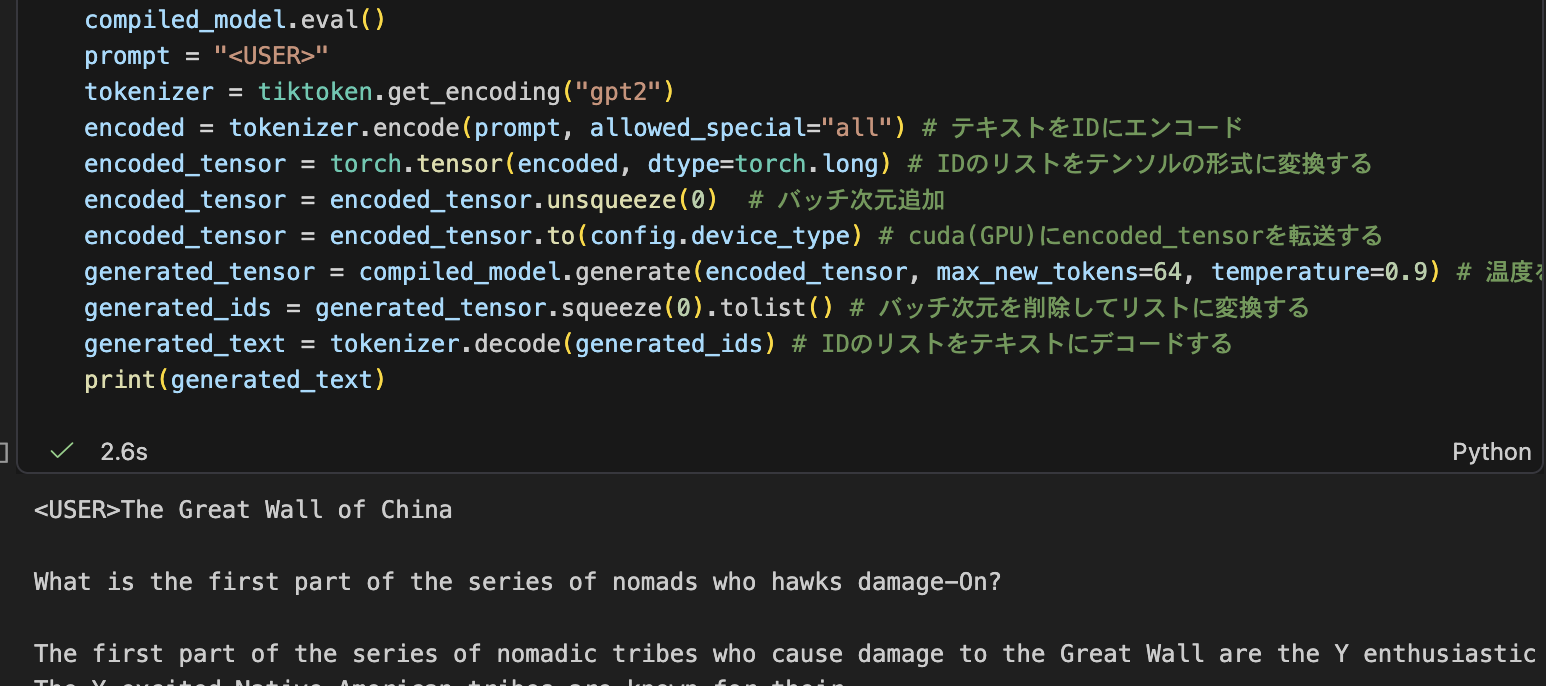

30回推論してみてください。1回は質問のようなものが出てくるはずです。

In [ ]:
compiled_model.eval()
prompt = "<USER>"
tokenizer = tiktoken.get_encoding("gpt2")
encoded = tokenizer.encode(prompt, allowed_special="all") # テキストをIDにエンコード
encoded_tensor = torch.tensor(encoded, dtype=torch.long) # IDのリストをテンソルの形式に変換する
encoded_tensor = encoded_tensor.unsqueeze(0)  # バッチ次元追加
encoded_tensor = encoded_tensor.to(config.device_type) # cuda(GPU)にencoded_tensorを転送する
generated_tensor = generate(compiled_model, encoded_tensor, max_new_tokens=64, temperature=0.9) # 温度を高めに設定
generated_ids = generated_tensor.squeeze(0).tolist() # バッチ次元を削除してリストに変換する
generated_text = tokenizer.decode(generated_ids) # IDのリストをテキストにデコードする
print(generated_text)

<USER>To provide a comprehensive answer to the question.

The question is: "What is the capital of France?"

Answer: The capital of France is Paris. The capital of France is Paris.<|endoftext|> configured in the script, "C flip a lid passag audio loop":

```python
import


質問っぽい文章の生成、確認できましたでしょうか？

ここで起きていることを、もう一度整理してみましょう。

今回のInstruction Tuningでは、質問文側の損失を `-100` でマスクしました。つまり、モデルは「質問文そのものを正解として当てる練習」はしていません。

それなのに、学習後のモデルに `<USER>` だけを渡すと、たまに質問文のような文章を生成します。これはかなり不思議な現象です。

同じような現象は、LLaMAのような強力なLLMでも観察されています。この現象に注目して、質問文と回答文のペアを自動で作ろうとする手法が **Magpie** です。論文は2024年に公開され、ICLR 2025で発表されています。

これまでは、Instruction Tuning用のデータを作るとき、ユーザーからの質問文や指示文は人間が用意することが多くありました。LLMに回答を書かせることはできても、良い質問文を大量に、しかも多様に作るのは難しいと考えられていたからです。

しかしMagpieでは、強力なLLMにユーザータグのような開始部分だけを与えることで、モデル自身に質問文を生成させます。そして、その質問文に対する回答も生成させれば、Instruction Tuningに使える「質問文と回答文のペア」を作れます。

つまり、強力なオープンウェイトモデルから、Instruction Tuning用のデータを自動的に作れるようになったわけです。

このChapterで使っているMagpieデータセットも、その考え方で作られたデータです。今回のデータは、MicrosoftのPhi-3をもとに生成されたものです。

`complied_model`を保存するよりも、`model`を保存した方が、後々使いやすいです。<br>

In [ ]:
model_path = "prompt_mask_instruction_tuned_model.pt"
torch.save(model.state_dict(), model_path)

In [ ]:
upload_file(repo_id=model_repo_id, repo_type="model", path_or_fileobj=model_path, path_in_repo=model_path)

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...nstruction_tuned_model.pt:  23%|##3       |  488MB / 2.09GB            

No files have been modified since last commit. Skipping to prevent empty commit.


CommitInfo(commit_url='https://huggingface.co/HayatoHongo/EveryonesGPT-checkpoints0603/commit/ec2b8ec76f8d8247466e0ca01c898f8ebc139560', commit_message='Upload prompt_mask_instruction_tuned_model.pt with huggingface_hub', commit_description='', oid='ec2b8ec76f8d8247466e0ca01c898f8ebc139560', pr_url=None, repo_url=RepoUrl('https://huggingface.co/HayatoHongo/EveryonesGPT-checkpoints0603', endpoint='https://huggingface.co', repo_type='model', repo_id='HayatoHongo/EveryonesGPT-checkpoints0603'), pr_revision=None, pr_num=None)

学習曲線を観察しましょう。

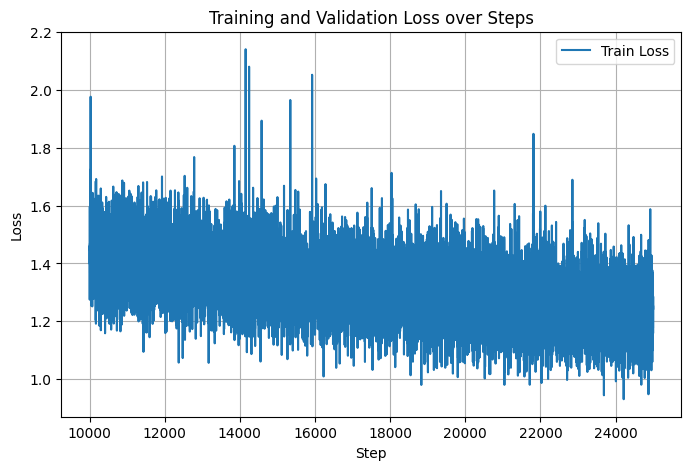

In [ ]:
# グラフ描画。
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.plot(trainer.steps, trainer.train_losses, label='Train Loss')

plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Training and Validation Loss over Steps')
plt.legend()
plt.grid(True)
plt.show()

**⚠️ 右上の 🔽 からランタイムを接続解除してクレジット消費を止めてください。** <label><input type="checkbox">接続解除した</label>

**Chapter 29: Magpie** <label><input type="checkbox"> Mark as Done</label>